# Shor's Algorithm

### Setup

In [1]:
import numpy as np
import pandas as pd
from fractions import Fraction
from math import floor, gcd, log

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit.transpiler import CouplingMap, generate_preset_pass_manager
from qiskit.visualization import plot_histogram

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

## Step 1: Map classical inputs to a quantum problem

### Background
Shor's algorithm for integer factorization utilizes an intermediary problem known as the order finding problem. In this section, we demonstrate how to solve the order finding problem using quantum phase estimation.

## Step 2: Optimize problem for quantum hardware execution

Specific example with N = 15 and a = 2

 Below, we construct the $M_2$ and the $controlled-M_2$ operations.




In [2]:
def M2mod15():
    """
    M2 (mod 15)
    """
    b = 2
    U = QuantumCircuit(4)

    U.swap(2, 3)
    U.swap(1, 2)
    U.swap(0, 1)

    U = U.to_gate()
    U.name = f"M_{b}"

    return U

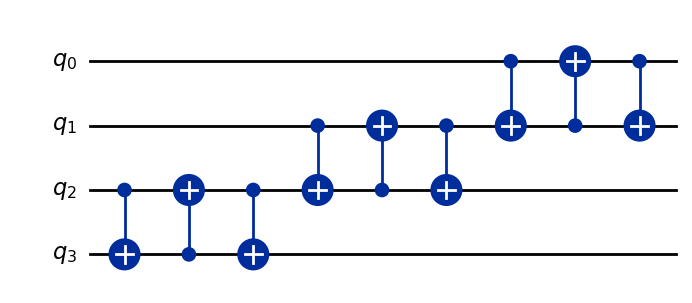

In [3]:
# Get the M2 operator
M2 = M2mod15()

# Add it to a circuit and plot
circ = QuantumCircuit(4)
circ.compose(M2, inplace=True)
circ.decompose(reps=2).draw(output="mpl", fold=-1)

In [4]:
def controlled_M2mod15():
    """
    Controlled M2 (mod 15)
    """
    b = 2
    U = QuantumCircuit(4)

    U.swap(2, 3)
    U.swap(1, 2)
    U.swap(0, 1)

    U = U.to_gate()
    U.name = f"M_{b}"
    c_U = U.control()

    return c_U

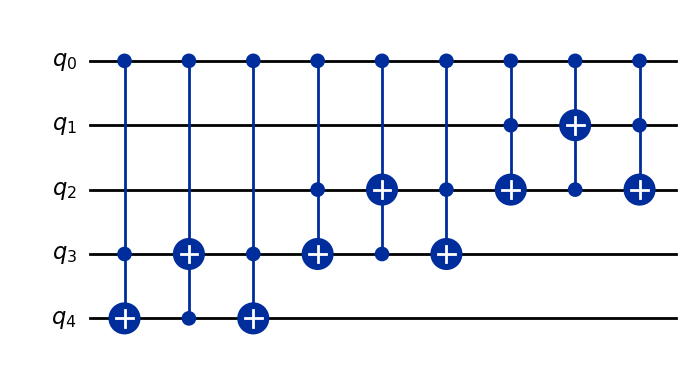

In [5]:
# Get the controlled-M2 operator
controlled_M2 = controlled_M2mod15()

# Add it to a circuit and plot
circ = QuantumCircuit(5)
circ.compose(controlled_M2, inplace=True)
circ.decompose(reps=1).draw(output="mpl", fold=-1)

Gates acting on more than two qubits will be further decomposed into two-qubit gates.

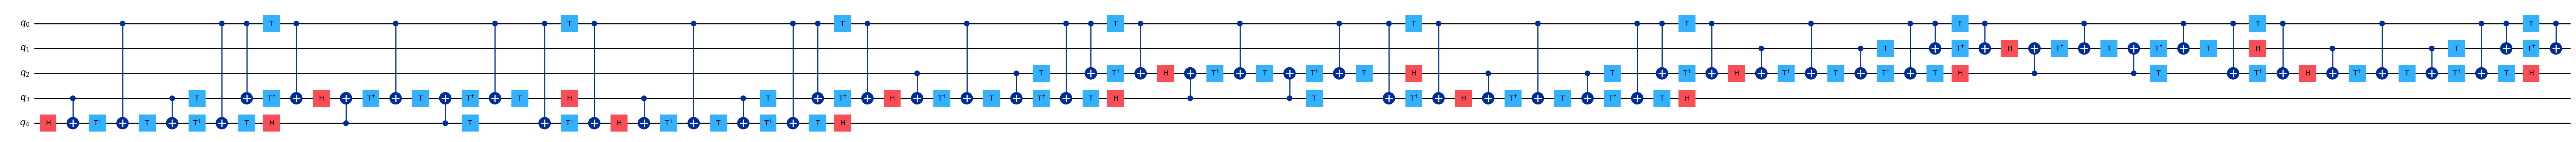

In [6]:
circ.decompose(reps=2).draw(output="mpl", fold=-1)

Now we need to construct the modular exponentiation operators. To obtain enough precision in the phase estimation, we will use eight qubits for the estimation measurement.

In [7]:
def a2kmodN(a, k, N):
    """
    Compute a^{2^k} (mod N)
    by repeated squaring
    """
    for _ in range(k):
        a = int(np.mod(a**2, N))
    return a

In [8]:
k_list = range(8)
b_list = [a2kmodN(2, k, 15) for k in k_list]

print(b_list)

[2, 4, 1, 1, 1, 1, 1, 1]


In [11]:
def M4mod15():
    """
    M4 (mod 15)
    """
    b = 4
    U = QuantumCircuit(4)

    U.swap(1, 3)
    U.swap(0, 2)

    U = U.to_gate()
    U.name = f"M_{b}"

    return U

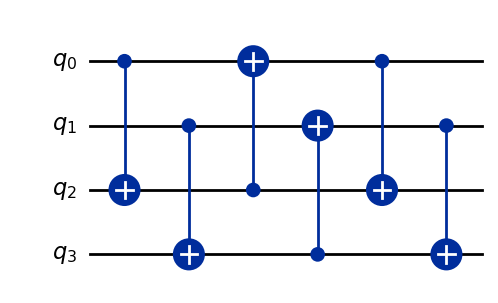

In [12]:
# Get the M4 operator
M4 = M4mod15()

# Add it to a circuit and plot
circ = QuantumCircuit(4)
circ.compose(M4, inplace=True)
circ.decompose(reps=2).draw(output="mpl", fold=-1)

In [13]:
def controlled_M4mod15():
    """
    Controlled M4 (mod 15)
    """
    b = 4
    U = QuantumCircuit(4)

    U.swap(1, 3)
    U.swap(0, 2)

    U = U.to_gate()
    U.name = f"M_{b}"
    c_U = U.control()

    return c_U

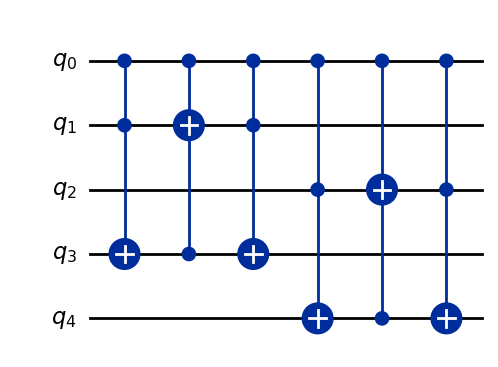

In [14]:
# Get the controlled-M4 operator
controlled_M4 = controlled_M4mod15()

# Add it to a circuit and plot
circ = QuantumCircuit(5)
circ.compose(controlled_M4, inplace=True)
circ.decompose(reps=1).draw(output="mpl", fold=-1)

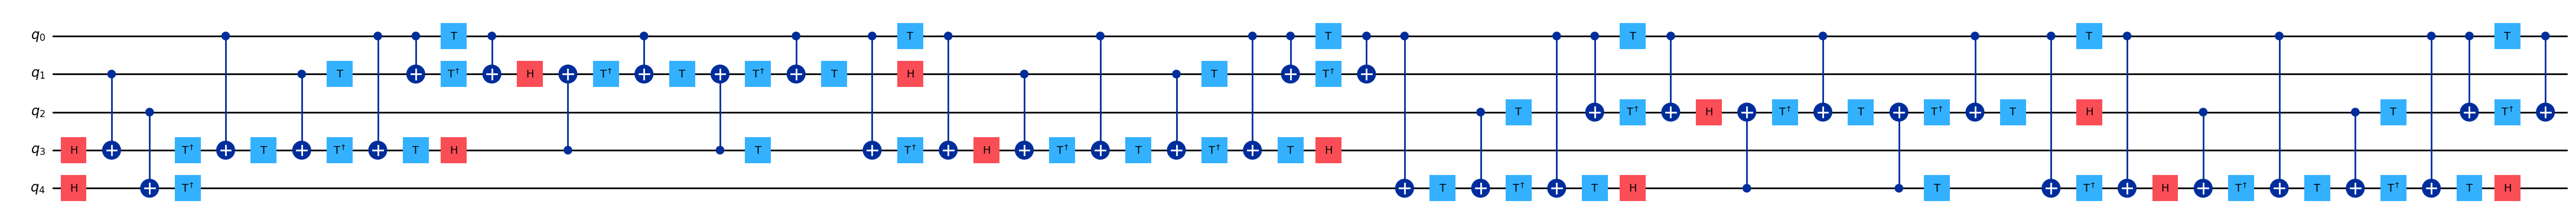

In [15]:
circ.decompose(reps=2).draw(output="mpl", fold=-1)